# 02 — Bet-Token Pilot

I need a small discrete betting vocabulary, but I do not want to choose its floor, cap, or spacing by intuition. Here I sample representative public shoe compositions, estimate their complete round-return distributions, calculate continuous half-Kelly fractions, and compare candidate token grids.

## The scoped approximation I make

Exact rational enumeration remains my verifier for play quality. It is not practical as the production labeler: a realistic composition with sequential split-hand correlations can take longer than a minute by itself.

For this vocabulary pilot and the production bet labels, I use seeded Monte Carlo rollouts with a documented six-deck H17, double-after-split, late-surrender basic-strategy policy for playing actions. Insurance remains composition-dependent because its exact decision is the inexpensive comparison against the one-third break-even probability. Each rollout still follows the complete casino mechanics and payout distribution, including naturals, insurance, surrender, doubles, and correlated split hands. Production play labels separately force every legal first action and use the same fixed policy only for later rollout decisions; I compare those labels against the exact oracle in the dataset methodology.

I keep the simulation configuration and standard errors visible so I do not claim more precision than the pilot supports.

In [1]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from blackjack.analysis import (
    SELECTED_BET_VOCABULARY,
    PilotConfiguration,
    analyze_vocabulary,
    candidate_vocabularies,
    run_bet_token_pilot,
)

/Users/pattrudel/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/mx/tjb7s2qs7vjdzq50cqzk4l7m0000gn/T/matplotlib-a0ph01pt because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


## Reproducible sample

I use four penetration strata from each of 24 deterministic shoes. I run 25,000 rounds for every sampled composition, giving me 2.4 million complete rounds. Re-running this cell with the same configuration reproduces the same compositions and outcomes.

In [2]:
configuration = PilotConfiguration(
    seed=20250725,
    shoe_count=24,
    samples_per_shoe=4,
    rollouts_per_composition=25_000,
)
observations = run_bet_token_pilot(configuration)
metrics = tuple(
    analyze_vocabulary(observations, vocabulary)
    for vocabulary in candidate_vocabularies()
)
selected_metrics = next(
    item for item in metrics if item.vocabulary == SELECTED_BET_VOCABULARY
)

len(observations), configuration.rollouts_per_composition * len(observations)

(96, 2400000)

In [3]:
half_kelly = tuple(item.half_kelly for item in observations)
mean_edge_error = sum(
    item.expected_profit_standard_error for item in observations
) / len(observations)
positive_edges = sum(value > 0 for value in half_kelly)
observed_range = f"{min(half_kelly) * 100:.3f}%-{max(half_kelly) * 100:.3f}%"

display(
    Markdown(
        f"""
- Sampled compositions: **{len(observations)}**
- Positive estimated half-Kelly fractions: **{positive_edges}**
- Observed half-Kelly range: **{observed_range}**
- Mean expected-return standard error: **{mean_edge_error * 100:.3f} percentage points**
"""
    )
)


- Sampled compositions: **96**
- Positive estimated half-Kelly fractions: **31**
- Observed half-Kelly range: **0.000%-0.995%**
- Mean expected-return standard error: **0.722 percentage points**


The average return uncertainty is larger than the finest candidate token spacing. That is an important constraint: a very large vocabulary would encode Monte Carlo noise as if it were meaningful policy precision.

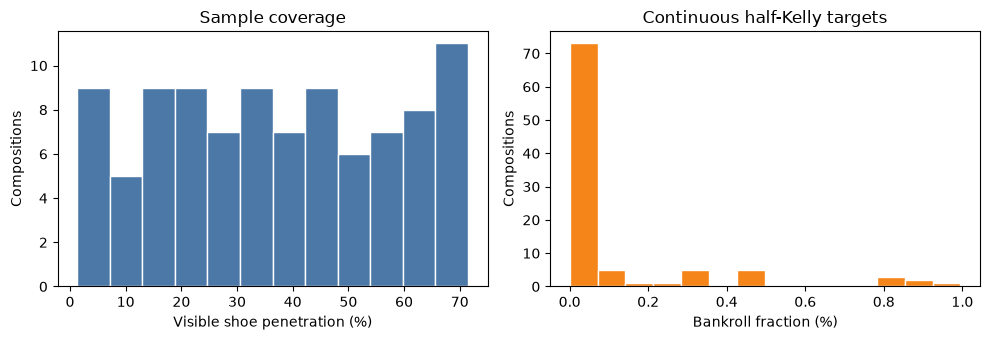

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(
    [item.sample.penetration * 100 for item in observations],
    bins=12,
    color="#4C78A8",
    edgecolor="white",
)
axes[0].set(
    title="Sample coverage",
    xlabel="Visible shoe penetration (%)",
    ylabel="Compositions",
)

axes[1].hist(
    [value * 100 for value in half_kelly],
    bins=14,
    color="#F58518",
    edgecolor="white",
)
axes[1].set(
    title="Continuous half-Kelly targets",
    xlabel="Bankroll fraction (%)",
    ylabel="Compositions",
)

fig.tight_layout()
plt.show()

Most sampled states do not have a positive estimated edge, so they accumulate at continuous half Kelly of zero. A casino round still needs a positive wager, which means the smallest token acts as my minimum wager rather than a literal zero-bet action.

In [5]:
header = (
    "| Candidate | Tokens | Floor | Cap | Mean rounding error | "
    "95th percentile error | Mean log-growth regret | Occupied classes |\n"
    "| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |"
)
rows = [
    "| "
    + " | ".join(
        (
            item.vocabulary.name,
            str(len(item.vocabulary.fractions)),
            f"{item.vocabulary.fractions[0] * 100:.2f}%",
            f"{item.vocabulary.fractions[-1] * 100:.2f}%",
            f"{item.mean_absolute_rounding_error * 100:.3f} pp",
            f"{item.p95_absolute_rounding_error * 100:.3f} pp",
            f"{item.mean_log_growth_regret:.2e}",
            str(item.occupied_classes),
        )
    )
    + " |"
    for item in metrics
]
display(Markdown("\n".join((header, *rows))))

| Candidate | Tokens | Floor | Cap | Mean rounding error | 95th percentile error | Mean log-growth regret | Occupied classes |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| selected-four-token | 4 | 0.10% | 1.30% | 0.091 pp | 0.151 pp | 9.87e-06 | 3 |
| five-token | 5 | 0.10% | 1.30% | 0.088 pp | 0.105 pp | 9.93e-06 | 4 |
| six-token | 6 | 0.10% | 1.30% | 0.084 pp | 0.100 pp | 1.00e-05 | 5 |
| compact | 5 | 0.10% | 2.00% | 0.107 pp | 0.206 pp | 1.11e-05 | 3 |
| balanced | 11 | 0.10% | 2.50% | 0.087 pp | 0.105 pp | 1.00e-05 | 5 |
| fine | 30 | 0.10% | 3.00% | 0.077 pp | 0.100 pp | 9.77e-06 | 8 |
| higher-floor | 10 | 0.25% | 2.50% | 0.205 pp | 0.250 pp | 2.63e-05 | 4 |
| wider-cap | 9 | 0.10% | 4.00% | 0.107 pp | 0.206 pp | 1.11e-05 | 3 |
| hybrid | 8 | 0.10% | 3.00% | 0.084 pp | 0.100 pp | 1.00e-05 | 5 |

I measure two different distortions. Rounding error tells me how far the token fraction is from continuous half Kelly. Log-growth regret measures only a decrease in expected logarithmic growth; I separately retain the absolute growth change because rounding upward can increase expected growth while also taking more risk than half Kelly intends.

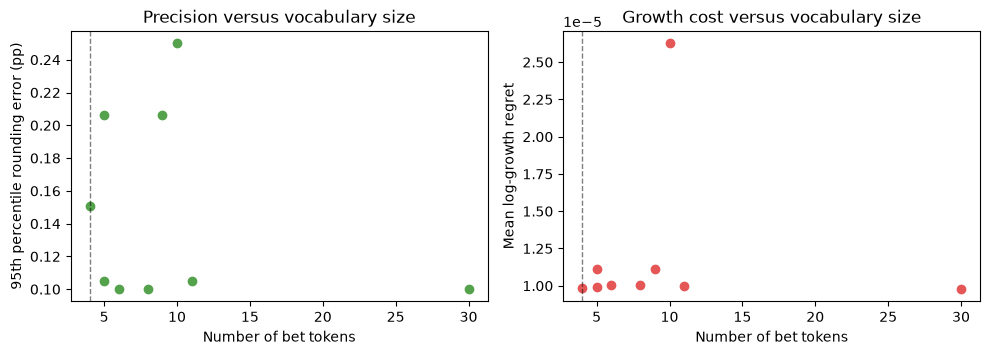

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
token_counts = [len(item.vocabulary.fractions) for item in metrics]

axes[0].scatter(
    token_counts,
    [item.p95_absolute_rounding_error * 100 for item in metrics],
    color="#54A24B",
)
axes[0].set(
    title="Precision versus vocabulary size",
    xlabel="Number of bet tokens",
    ylabel="95th percentile rounding error (pp)",
)

axes[1].scatter(
    token_counts,
    [item.mean_log_growth_regret for item in metrics],
    color="#E45756",
)
axes[1].set(
    title="Growth cost versus vocabulary size",
    xlabel="Number of bet tokens",
    ylabel="Mean log-growth regret",
)

for axis in axes:
    axis.axvline(4, color="black", linestyle="--", linewidth=1, alpha=0.5)

fig.tight_layout()
plt.show()

The four-token candidate covers the full observed range and keeps its 95th-percentile rounding error below 0.15 percentage points. Finer grids make only a small improvement relative to the pilot's sampling uncertainty, so four tokens are enough for this first model.

In [7]:
token_header = "| Token | Bankroll fraction | Pilot examples |\n| --- | ---: | ---: |"
token_rows = [
    f"| `{token.token}` | {token.bankroll_fraction * 100:.2f}% | {count} |"
    for token, count in zip(
        SELECTED_BET_VOCABULARY.tokens,
        selected_metrics.class_counts,
        strict=True,
    )
]
display(Markdown("\n".join((token_header, *token_rows))))

| Token | Bankroll fraction | Pilot examples |
| --- | ---: | ---: |
| `<BET_MIN>` | 0.10% | 80 |
| `<BET_LOW>` | 0.50% | 10 |
| `<BET_MEDIUM>` | 0.90% | 6 |
| `<BET_HIGH>` | 1.30% | 0 |

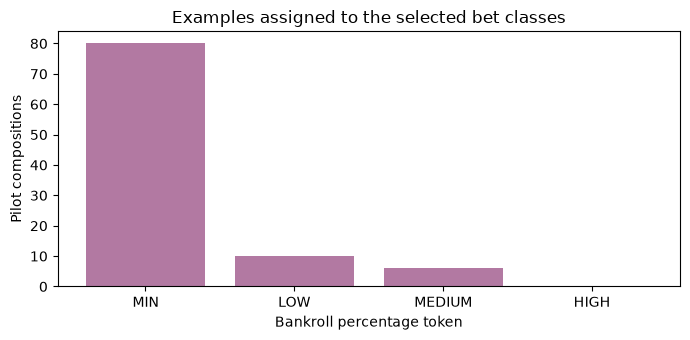

In [8]:
fig, axis = plt.subplots(figsize=(7, 3.5))
axis.bar(
    [
        token.token.removeprefix("<BET_").removesuffix(">")
        for token in SELECTED_BET_VOCABULARY.tokens
    ],
    selected_metrics.class_counts,
    color="#B279A2",
)
axis.set(
    title="Examples assigned to the selected bet classes",
    xlabel="Bankroll percentage token",
    ylabel="Pilot compositions",
)
fig.tight_layout()
plt.show()

The minimum class is intentionally dominant. Most representative shoe states have no positive estimated edge, so half Kelly is zero and the nearest playable wager is 0.10%. This small pilot does not populate the highest class; I retain it as headroom for rarer favorable compositions in the larger production sample rather than inventing still more bet tokens to make the histogram look balanced.

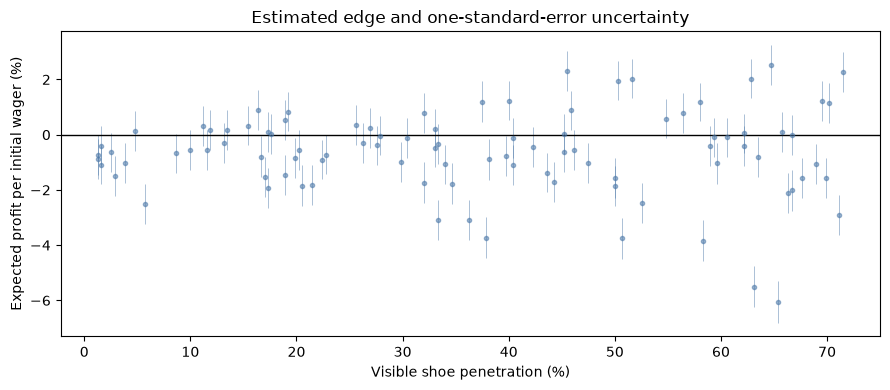

In [9]:
ordered = sorted(observations, key=lambda item: item.sample.penetration)
fig, axis = plt.subplots(figsize=(9, 4))
axis.errorbar(
    [item.sample.penetration * 100 for item in ordered],
    [item.expected_profit * 100 for item in ordered],
    yerr=[item.expected_profit_standard_error * 100 for item in ordered],
    fmt="o",
    markersize=3,
    alpha=0.55,
    linewidth=0.6,
    color="#4C78A8",
)
axis.axhline(0, color="black", linewidth=1)
axis.set(
    title="Estimated edge and one-standard-error uncertainty",
    xlabel="Visible shoe penetration (%)",
    ylabel="Expected profit per initial wager (%)",
)
fig.tight_layout()
plt.show()

## Decision

I will begin with four categorical bet tokens: `<BET_MIN>`, `<BET_LOW>`, `<BET_MEDIUM>`, and `<BET_HIGH>`. Their versioned fractions are 0.10%, 0.50%, 0.90%, and 1.30% of bankroll. This compact vocabulary covers the observed continuous targets and keeps the 95th-percentile rounding error near 0.15 percentage points. The pilot does not populate `<BET_HIGH>`, so I treat that token as explicit headroom to test against the larger production sample rather than as a fact established by these 96 states.

This is a versioned experimental choice rather than a permanent truth. Once the seeded production labeling pipeline produces a larger set of continuous half-Kelly targets, I can rerun the same comparison and revise the vocabulary if the stronger evidence warrants it.